# Import Libraries & Setup Environment
📦 What We Used

Pandas / NumPy → data handling

NLTK → sentence segmentation, stopwords

spaCy → lemmatization + NER

Scikit-learn → TF-IDF, NMF

WordCloud / Matplotlib → visualization

In [5]:
import pandas as pd
import numpy as np

In [6]:
# NLP
import spacy
nlp = spacy.load('en_core_web_sm')

In [7]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import sent_tokenize
# ML
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF, LatentDirichletAllocation

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

nlp = spacy.load("en_core_web_sm")
stop_words = set(stopwords.words("english"))

# Dataset Loading
📌 What We Did

Loaded customer complaint text into a DataFrame:

complaint_id
complaint_text

In [ ]:
complaints = [
    
]

# Create DataFrame
df = pd.DataFrame({
    'complaint_id': range(1, 101),
    'complaint_text': np.random.choice(complaints, 100)
})

print(df)

In [9]:
complaints = [
    "My refund is delayed for 10 days",
    "App crashes whenever I try to pay",
    "Delivery boy did not come to my area",
    "Refund failed for SBI users in Bangalore",
    "App freezes after recent update",
    "Order delivery is late in Delhi",
    "Product not delivered",
    "Service issue",
    "Wrong order",
    "Refund not received",
    "Poor customer support",
    "Delivery took too long",
    "Item was damaged",
    "Wrong size received",
    "Product doesn't match description",
    "Payment issue",
    "No response from seller",
    "Return process complicated",
    "Quality not as expected",
    "Missing parts/accessories",
    "App/UI issue"
]

# Create DataFrame
df = pd.DataFrame({
    'complaint_id': range(1, 1001),
    'complaint_text': np.random.choice(complaints, 1000)
})

print(df.head())

   complaint_id                    complaint_text
0             1               Refund not received
1             2  My refund is delayed for 10 days
2             3           No response from seller
3             4                       Wrong order
4             5   Order delivery is late in Delhi


# STEP 3: Sentence Segmentation 
📌 What We Did

We split each complaint into individual sentences.

In [10]:
def sentence_split(text):
    return sent_tokenize(text)

df["sentences"] = df["complaint_text"].apply(sentence_split)
df = df.explode("sentences").reset_index(drop=True)
df.head()

,complaint_id,complaint_text,sentences
0,1,Refund not received,Refund not received
1,2,My refund is delayed for 10 days,My refund is delayed for 10 days
2,3,No response from seller,No response from seller
3,4,Wrong order,Wrong order
4,5,Order delivery is late in Delhi,Order delivery is late in Delhi


# STEP 4: Text Cleaning & Lemmatization
📌 What We Did

For each sentence:

Lowercased text
Removed stopwords (is, the, and)
Removed non-alphabetic words
Applied lemmatization

In [11]:
def preprocess(text):
    doc = nlp(text.lower())
    tokens = []
    for token in doc:
        if token.is_alpha and token.text not in stop_words:
            tokens.append(token.lemma_)
    return " ".join(tokens)

df["clean_text"] = df["sentences"].apply(preprocess)
df.head()

,complaint_id,complaint_text,sentences,clean_text
0,1,Refund not received,Refund not received,refund receive
1,2,My refund is delayed for 10 days,My refund is delayed for 10 days,refund delay day
2,3,No response from seller,No response from seller,response seller
3,4,Wrong order,Wrong order,wrong order
4,5,Order delivery is late in Delhi,Order delivery is late in Delhi,order delivery late delhi


# STEP 5: TF-IDF Vectorization
📌 What We Did

Converted cleaned text into numerical vectors using TF-IDF.

In [12]:
vectorizer = TfidfVectorizer(
    max_df=0.9,
    min_df=2,
    ngram_range=(1,2)
)

tfidf_matrix = vectorizer.fit_transform(df["clean_text"])

# STEP 6: Topic Modeling Using NMF 
📌 What We Did

Applied Non-Negative Matrix Factorization (NMF) to TF-IDF vectors.

In [13]:
n_topics = 3

nmf = NMF(n_components=n_topics, random_state=42)
topic_matrix = nmf.fit_transform(tfidf_matrix)

df["topic"] = topic_matrix.argmax(axis=1)
df.head()

,complaint_id,complaint_text,sentences,clean_text,topic
0,1,Refund not received,Refund not received,refund receive,0
1,2,My refund is delayed for 10 days,My refund is delayed for 10 days,refund delay day,0
2,3,No response from seller,No response from seller,response seller,2
3,4,Wrong order,Wrong order,wrong order,2
4,5,Order delivery is late in Delhi,Order delivery is late in Delhi,order delivery late delhi,2


# STEP 7: Root Cause Keyword Extraction
📌 What We Did

For each topic:

Extracted top keywords contributing to that topic

In [14]:
feature_names = vectorizer.get_feature_names_out()

def get_topic_keywords(model, n_words=8):
    topics = {}
    for idx, topic in enumerate(model.components_):
        top_words = [feature_names[i] for i in topic.argsort()[:-n_words-1:-1]]
        topics[idx] = top_words
    return topics

topic_keywords = get_topic_keywords(nmf)
topic_keywords

{0: ['refund',
  'refund receive',
  'refund delay',
  'day',
  'delay day',
  'delay',
  'receive',
  'sbi user'],
 1: ['issue',
  'service',
  'service issue',
  'payment issue',
  'payment',
  'ui issue',
  'ui',
  'app ui'],
 2: ['wrong',
  'order',
  'wrong order',
  'delivery',
  'delivery take',
  'take',
  'take long',
  'long']}

# STEP 8: Complaint Type Labeling (Vocabulary Matching)
📌 What We Did

Mapped topics to human-readable labels using keyword matching.

In [15]:
complaint_vocab = {
    "Refund Issue": ["refund", "payment", "failed", "money"],
    "App Crash": ["app", "crash", "freeze", "update"],
    "Delivery Issue": ["delivery", "late", "area", "boy"]
}

def label_topic(words):
    scores = {}
    for label, vocab in complaint_vocab.items():
        scores[label] = len(set(words) & set(vocab))
    return max(scores, key=scores.get)

topic_labels = {
    topic: label_topic(words)
    for topic, words in topic_keywords.items()
}

df["complaint_type"] = df["topic"].map(topic_labels)
df.head()

,complaint_id,complaint_text,sentences,clean_text,topic,complaint_type
0,1,Refund not received,Refund not received,refund receive,0,Refund Issue
1,2,My refund is delayed for 10 days,My refund is delayed for 10 days,refund delay day,0,Refund Issue
2,3,No response from seller,No response from seller,response seller,2,Delivery Issue
3,4,Wrong order,Wrong order,wrong order,2,Delivery Issue
4,5,Order delivery is late in Delhi,Order delivery is late in Delhi,order delivery late delhi,2,Delivery Issue


# STEP 9: Named Entity Recognition (NER)
📌 What We Did

Used spaCy NER to extract:

Organizations (banks, companies)
Locations (cities, regions)

In [16]:
def extract_entities(text):
    doc = nlp(text)
    products, locations, orgs = [], [], []

    for ent in doc.ents:
        if ent.label_ == "ORG":
            orgs.append(ent.text)
        elif ent.label_ in ["GPE", "LOC"]:
            locations.append(ent.text)

    return products, locations, orgs

df[["products", "locations", "organizations"]] = df["sentences"].apply(
    lambda x: pd.Series(extract_entities(x))
)

df.head()

,complaint_id,complaint_text,sentences,clean_text,topic,complaint_type,products,locations,organizations
0,1,Refund not received,Refund not received,refund receive,0,Refund Issue,[],[],[]
1,2,My refund is delayed for 10 days,My refund is delayed for 10 days,refund delay day,0,Refund Issue,[],[],[]
2,3,No response from seller,No response from seller,response seller,2,Delivery Issue,[],[],[]
3,4,Wrong order,Wrong order,wrong order,2,Delivery Issue,[],[],[]
4,5,Order delivery is late in Delhi,Order delivery is late in Delhi,order delivery late delhi,2,Delivery Issue,[],[Delhi],[]


# STEP 10: Word Clouds & Visualization
📌 What We Did

Generated word clouds per complaint cluster.

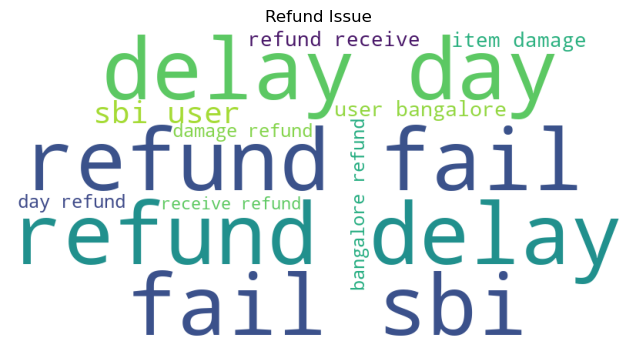

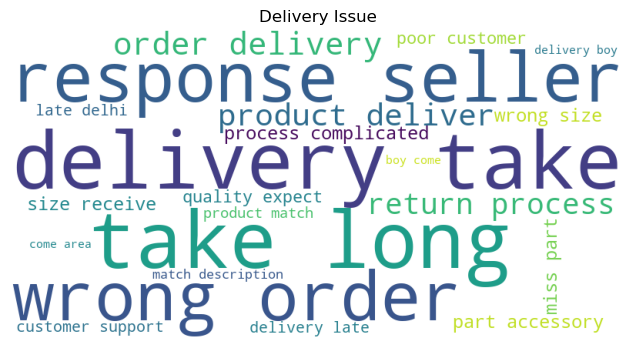

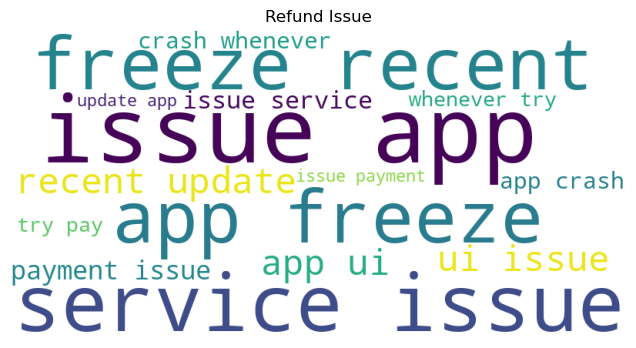

In [17]:
for topic in df["topic"].unique():
    text = " ".join(df[df["topic"] == topic]["clean_text"])
    wc = WordCloud(width=800, height=400, background_color="white").generate(text)
    
    plt.figure(figsize=(8,4))
    plt.imshow(wc)
    plt.axis("off")
    plt.title(topic_labels[topic])
    plt.show()

# STEP 11: Final Business Summary
📌 What We Produced

For each complaint category:

Number of complaints

Root cause keywords

Affected locations

Affected organizations

In [18]:
summary = df.groupby("complaint_type").agg({
    "clean_text": "count",
    "locations": lambda x: list(set(sum(x, []))),
    "organizations": lambda x: list(set(sum(x, [])))
}).rename(columns={"clean_text": "complaint_count"})

summary

,complaint_count,locations,organizations
complaint_type,,,
Delivery Issue,545,[Delhi],[]
Refund Issue,455,[],"[SBI, App/UI]"


I built an end-to-end NLP pipeline that segments customer complaints, clusters them using NMF topic modeling, identifies root causes via keyword analysis, and extracts affected entities using NER to support business decision-making.